In [ ]:
import pandas as pd
import numpy as np
print(f'pandas version: {pd.__version__}')


pandas version: 2.3.3


In [83]:
df = pd.read_csv('../data/exchange_rates.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 24 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Unnamed: 0                                 5217 non-null   int64 
 1   Time Serie                                 5217 non-null   object
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   object
 3   EURO AREA - EURO/US$                       5217 non-null   object
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   object
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   object
 6   BRAZIL - REAL/US$                          5217 non-null   object
 7   CANADA - CANADIAN DOLLAR/US$               5217 non-null   object
 8   CHINA - YUAN/US$                           5217 non-null   object
 9   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   object
 10  INDIA - INDIAN RUPEE/US$            

In [69]:
pd.set_option("display.max_columns", None)
df.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,MEXICO - MEXICAN PESO/US$,SOUTH AFRICA - RAND/US$,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
0,0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,43.55,1128,9.4015,6.126,1.6563,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97
1,1,2000-01-04,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,1122.5,9.457,6.085,1.6535,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13
2,2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,43.55,1135,9.535,6.07,1.656,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1
3,3,2000-01-06,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,43.55,1146.5,9.567,6.08,1.6655,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62
4,4,2000-01-07,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,43.55,1138,9.52,6.057,1.6625,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3


In [57]:
kr_uk_df = df[['Time Serie', 'KOREA - WON/US$', 'UNITED KINGDOM - UNITED KINGDOM POUND/US$']].copy()
kr_uk_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 3 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Time Serie                                 5217 non-null   object
 1   KOREA - WON/US$                            5217 non-null   object
 2   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   object
dtypes: object(3)
memory usage: 122.4+ KB


In [58]:
kr_uk_df['KOREA - WON/US$'] = pd.to_numeric(kr_uk_df['KOREA - WON/US$'], errors="coerce")
kr_uk_df['UNITED KINGDOM - UNITED KINGDOM POUND/US$'] = pd.to_numeric(kr_uk_df['UNITED KINGDOM - UNITED KINGDOM POUND/US$'], errors="coerce")

In [59]:
print(kr_uk_df['KOREA - WON/US$'].value_counts())
kr_uk_df['KOREA - WON/US$'].unique()

KOREA - WON/US$
1180.00    14
1115.00    13
1182.00    13
1186.00    13
1160.00    13
1284.00    12
1153.00    11
1171.00    11
1110.00    11
1128.00    10
1135.00    10
1179.00    10
1181.00    10
1173.00    10
1116.00    10
1192.00    10
1155.00    10
1149.00    10
1185.00     9
1178.00     9
1300.00     9
1150.00     9
1146.00     9
1158.00     9
1140.00     9
1157.00     9
1133.00     8
1124.00     8
1118.00     8
1121.00     8
1140.50     8
1170.00     8
1152.00     8
1120.00     8
1296.00     8
1156.00     8
1286.00     8
1189.00     8
1119.00     7
1183.00     7
1117.00     7
1130.00     7
1201.00     7
1111.00     7
1016.00     7
1165.00     7
1154.00     7
1166.00     7
1126.00     7
1127.00     7
1168.00     7
1139.00     7
1303.00     7
1191.00     7
1147.00     6
1114.00     6
1123.00     6
1138.00     6
1202.00     6
1200.00     6
1298.00     6
1174.00     6
1009.00     6
944.60      6
1290.00     6
1305.00     6
1175.00     6
1161.00     6
1187.00     6
1307.00     6
1149

array([1128.  , 1122.5 , 1135.  , ..., 1160.87, 1155.75, 1155.46],
      shape=(3423,))

In [60]:
print(kr_uk_df.dtypes)
kr_uk_df.describe().round(2)

Time Serie                                    object
KOREA - WON/US$                              float64
UNITED KINGDOM - UNITED KINGDOM POUND/US$    float64
dtype: object


,KOREA - WON/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$
count,5019.00,5019.00
mean,1125.44,0.64
std,103.48,0.08
min,903.20,0.47
25%,1067.36,0.59
50%,1127.76,0.64
75%,1180.00,0.69
max,1570.10,0.83


In [61]:

print(type(kr_uk_df))
kr_uk_df = kr_uk_df.sort_values(by='KOREA - WON/US$', ascending=False)
kr_uk_df.info()
kr_uk_df.head()

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
Index: 5217 entries, 2390 to 5212
Data columns (total 3 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Time Serie                                 5217 non-null   object 
 1   KOREA - WON/US$                            5019 non-null   float64
 2   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5019 non-null   float64
dtypes: float64(2), object(1)
memory usage: 163.0+ KB


,Time Serie,KOREA - WON/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$
2390,2009-03-02,1570.10,0.7148
2393,2009-03-05,1567.10,0.7080
2391,2009-03-03,1551.20,0.7126
2392,2009-03-04,1550.95,0.7071
2394,2009-03-06,1549.60,0.7087


In [64]:
import matplotlib.pyplot as plt

# 폰트 설정: 한글 깨짐을 방지하기 위해
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # - 기호 깨짐 방지

2000-01-03
2009-12-31
2019-12-31


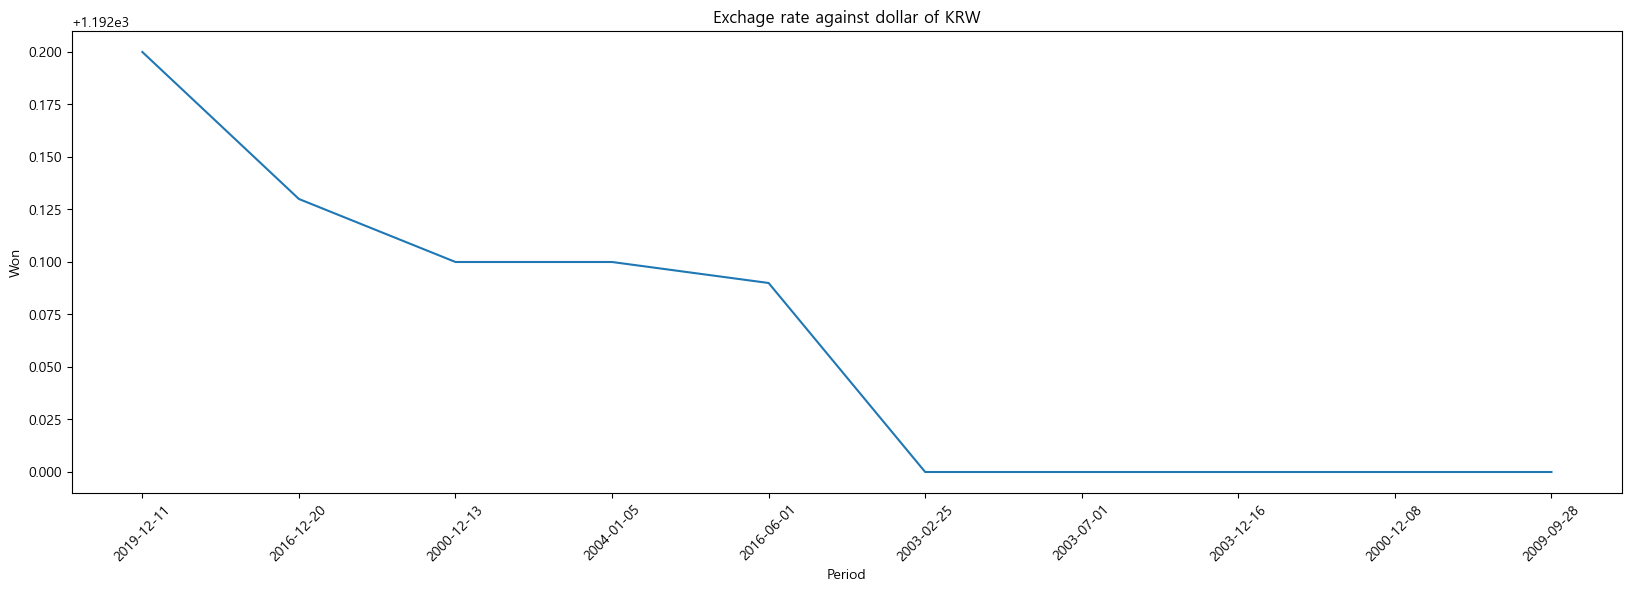

In [88]:
x = kr_uk_df['Time Serie'][1000:1010]
y1 = kr_uk_df['KOREA - WON/US$'][1000:1010]
y2 = kr_uk_df['UNITED KINGDOM - UNITED KINGDOM POUND/US$'][1000:1010]

plt.figure(figsize=(20, 6))
plt.plot(x, y1)
# plt.plot(x, y2)
plt.title('Exchage rate against dollar of KRW')

plt.xlabel('Period')
plt.ylabel('Won')

df_len = len(df)
print(df.iloc[0]['Time Serie'])
print(df.iloc[df_len // 2]['Time Serie'])
print(df.iloc[df_len-1]['Time Serie'])


plt.xticks(x, rotation=45)

plt.show()

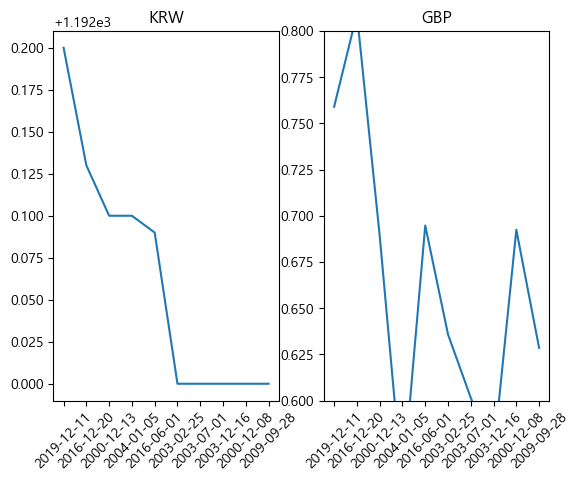

In [103]:
plt.subplot(1, 2, 1)
plt.title('KRW')
plt.plot(x, y1)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.ylim(0.6, 0.8)
plt.title('GBP')
plt.plot(x, y2)
plt.xticks(rotation=45)

plt.show()